In [51]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV

In [103]:
df = pd.read_csv("C:\\Users\\hp\\Desktop\\project_intern\\New folder\\B13-ExoHabitAI\\data\\processed\\preprocessed.csv")

In [53]:
df.head()

,sy_dist,pl_orbper,pl_orbsmax,pl_rade,pl_masse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_lum,st_met,habitability_score,stellar_compatibility,orbital_stability,habitable
0,396.3320,406.000000,0.101,2.310,152.00,0.33,88.24,802.0,29564.0,0.203,0.480,-0.07917,0.00,517.28817,5.116649,4019.801980,1
1,15.4614,4.229300,0.101,2.310,152.00,0.00,88.24,802.0,5773.0,1.290,0.960,-0.07917,0.20,517.28817,0.999135,41.874257,1
2,12.5855,0.736543,0.101,1.856,152.00,0.00,88.24,802.0,5272.0,0.943,0.905,-0.07917,0.37,516.83417,0.912426,7.292505,1
3,12.5855,0.736547,0.101,1.947,8.59,0.00,88.24,802.0,5620.0,0.980,1.015,-0.07917,0.00,516.92517,0.972655,7.292549,1
4,12.5855,0.737000,0.101,1.897,7.74,0.00,88.24,802.0,5172.0,0.954,0.873,-0.07917,0.35,516.87517,0.895119,7.297030,1


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14299 entries, 0 to 14298
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sy_dist                14299 non-null  float64
 1   pl_orbper              14299 non-null  float64
 2   pl_orbsmax             14299 non-null  float64
 3   pl_rade                14299 non-null  float64
 4   pl_masse               14299 non-null  float64
 5   pl_orbeccen            14299 non-null  float64
 6   pl_insol               14299 non-null  float64
 7   pl_eqt                 14299 non-null  float64
 8   st_teff                14299 non-null  float64
 9   st_rad                 14299 non-null  float64
 10  st_mass                14299 non-null  float64
 11  st_lum                 14299 non-null  float64
 12  st_met                 14299 non-null  float64
 13  habitability_score     14299 non-null  float64
 14  stellar_compatibility  14299 non-null  float64
 15  or

##### 2. Dataset Preparation for ML input file

In [55]:
features = [
    'pl_eqt',
    'pl_rade',
    'pl_orbsmax',
    'pl_orbper',
    'st_teff',
    'st_lum',
    'stellar_compatibility',
    'orbital_stability'
]

In [56]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['habitable']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### 3. Baseline Model Selection

In [57]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [58]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
y_pred_lr = model_lr.predict(X_test)
lr_acc = accuracy_score(y_test, y_pred_lr)

In [60]:
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [61]:
dt_pred = dt_model.predict(X_test)

In [62]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       369
           1       1.00      1.00      1.00      2491

    accuracy                           1.00      2860
   macro avg       1.00      1.00      1.00      2860
weighted avg       1.00      1.00      1.00      2860



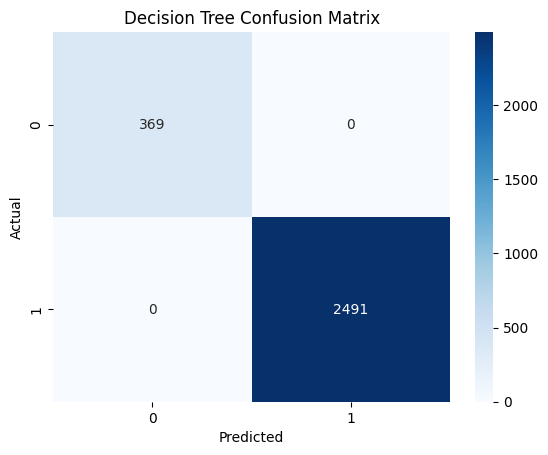

In [63]:
cm = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [64]:
dt_acc = accuracy_score(y_test, dt_pred)

##### 4. Primary Model Candidates

In [65]:
model_rf = RandomForestClassifier(n_estimators=200, random_state=42)
model_rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
y_pred_rf = model_rf.predict(X_test)
rf_acc = accuracy_score(y_test, y_pred_rf)

In [67]:
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [68]:
y_pred_xgb = model_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

In [69]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc,
        dt_acc,
        rf_acc,
        xgb_acc
    ]
}
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.996853
1        Decision Tree  1.000000
2        Random Forest  1.000000
3              XGBoost  1.000000


###### Hyperparameter tuining

In [84]:
import joblib

joblib.dump(
    rf_pipeline,
    r"C:\Users\hp\Desktop\project_intern\New folder\B13-ExoHabitAI\models\random_forest.pkl"
)
joblib.dump(
    xgb_pipeline,
    r"C:\Users\hp\Desktop\project_intern\New folder\B13-ExoHabitAI\models\xgboost.pkl"
)

['C:\\Users\\hp\\Desktop\\project_intern\\New folder\\B13-ExoHabitAI\\models\\xgboost.pkl']

In [71]:
params = {
    'C':[0.01,0.1,1,10],
    'solver':['lbfgs','liblinear']
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid=params,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best Score: 0.9994754862540172


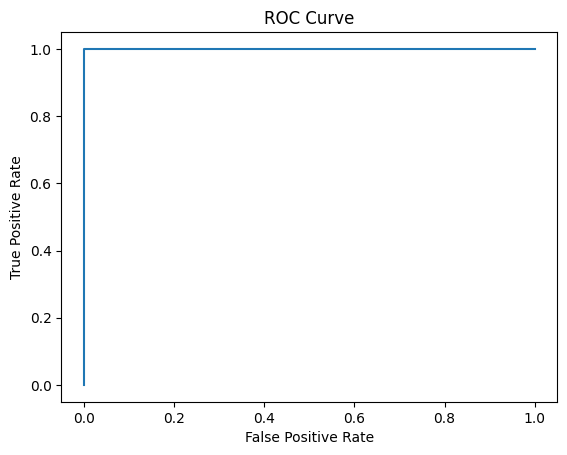

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       369
           1       1.00      1.00      1.00      2491

    accuracy                           1.00      2860
   macro avg       1.00      0.99      0.99      2860
weighted avg       1.00      1.00      1.00      2860



In [85]:
y_prob = model_lr.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print(classification_report(y_test, y_pred_lr))

In [86]:
rf_params = {

    'n_estimators':[100,200,300],
    'max_depth':[5,10,20,None],
    'min_samples_split':[2,5,10]

}

rf_grid = GridSearchCV(

    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1

)

rf_grid.fit(X_train, y_train)

print("Best RF Parameters:", rf_grid.best_params_)

Best RF Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


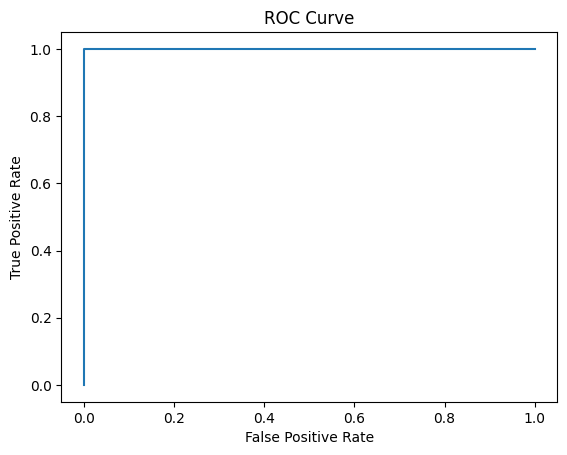

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       369
           1       1.00      1.00      1.00      2491

    accuracy                           1.00      2860
   macro avg       1.00      1.00      1.00      2860
weighted avg       1.00      1.00      1.00      2860



In [87]:
y_prob = model_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print(classification_report(y_test, y_pred_rf))

In [88]:
import xgboost
from xgboost import XGBClassifier

xgb_params = {

    'n_estimators':[100,200],
    'max_depth':[3,6,10],
    'learning_rate':[0.01,0.1,0.2]

}

xgb_grid = GridSearchCV(

    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1

)

xgb_grid.fit(X_train, y_train)

print("Best XGB Parameters:", xgb_grid.best_params_)

Best XGB Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}


C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [15:22:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


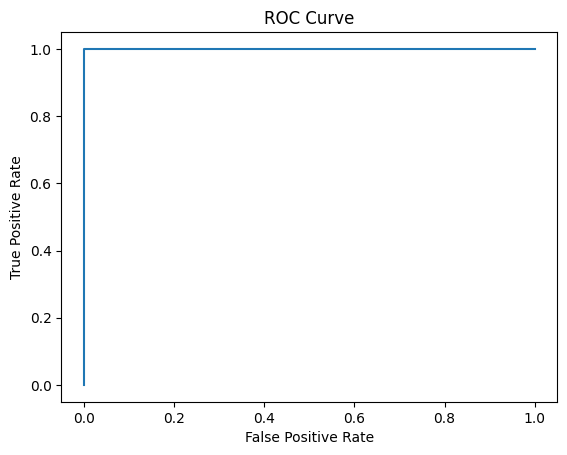

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       369
           1       1.00      1.00      1.00      2491

    accuracy                           1.00      2860
   macro avg       1.00      1.00      1.00      2860
weighted avg       1.00      1.00      1.00      2860



In [89]:
y_prob = model_xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()
print(classification_report(y_test, y_pred_xgb))

In [90]:
lr_pred = model_lr.predict(X_test)
rf_pred = model_rf.predict(X_test)
xgb_pred = model_xgb.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("XGBoost:", accuracy_score(y_test, xgb_pred))

Logistic Regression: 0.9968531468531469
Random Forest: 1.0
XGBoost: 1.0


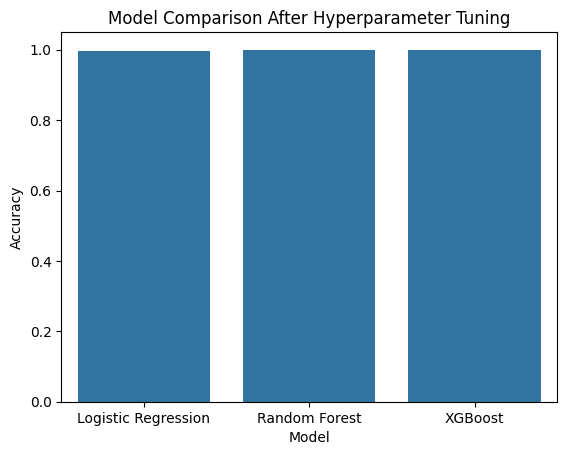

In [91]:
results = {

    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]

}

results_df = pd.DataFrame(results)

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Comparison After Hyperparameter Tuning")

plt.show()

In [94]:
final_model = model_rf

In [95]:
importance = model_rf.feature_importances_

feat_imp = pd.Series(importance, index=features)

print(feat_imp.sort_values(ascending=False))

pl_rade                  0.911243
st_lum                   0.036980
pl_orbper                0.018718
orbital_stability        0.018630
st_teff                  0.007507
stellar_compatibility    0.006923
pl_orbsmax               0.000000
pl_eqt                   0.000000
dtype: float64


##### Feature Importance

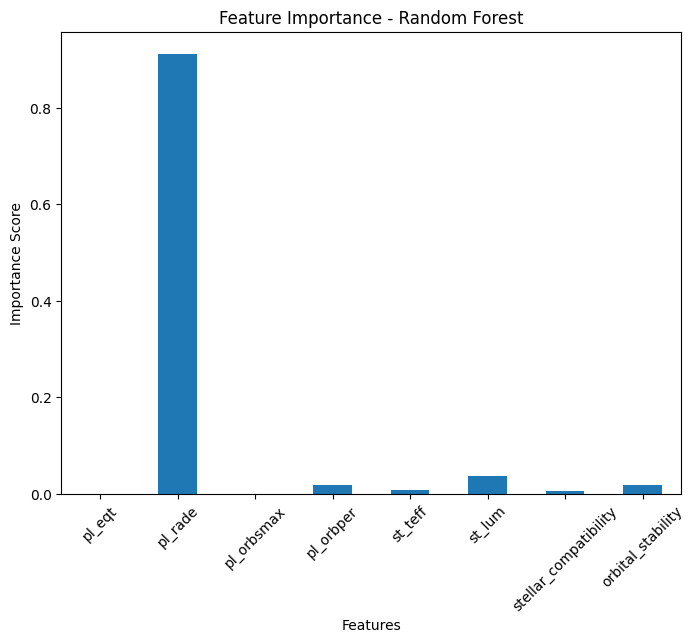

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

feat_imp.plot(kind="bar")

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

In [104]:
import os

# create folder if it doesn't exist
os.makedirs("data/processed", exist_ok=True)

# Predict probabilities
habitability_prob = final_model.predict_proba(X)[:,1]

# Create score
df["habitability_score"] = habitability_prob

# Rank planets
df_ranked = df.sort_values(
    by="habitability_score",
    ascending=False
)

# Add rank
df_ranked["rank"] = range(1, len(df_ranked)+1)

# Save file
df_ranked.to_csv(
    "C:\\Users\\hp\\Desktop\\project_intern\\New folder\\B13-ExoHabitAI\\data\\processed\\habitability_ranked.csv",
    index=False
)

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [105]:
df_ranked

,sy_dist,pl_orbper,pl_orbsmax,pl_rade,pl_masse,pl_orbeccen,pl_insol,pl_eqt,st_teff,st_rad,st_mass,st_lum,st_met,habitability_score,stellar_compatibility,orbital_stability,habitable,rank
53,253.0260,2.131740,0.101,0.6920,152.0,0.0,88.24,802.0,5620.0,0.957000,0.780000,-0.07917,0.00,0.200,0.972655,21.106337,1,1
7070,340.9650,3.032640,0.101,0.6942,152.0,0.0,88.24,802.0,5640.0,0.921000,0.962000,-0.07917,0.06,0.200,0.976116,30.026138,1,2
924,124.4580,4.383930,0.101,0.7010,152.0,0.0,88.24,802.0,5620.0,0.371000,0.960000,-0.07917,0.00,0.200,0.972655,43.405248,1,3
9917,88.7832,2.465026,0.101,0.6700,152.0,0.0,88.24,802.0,6192.0,1.230000,1.090000,-0.07917,-0.13,0.200,1.071651,24.406200,1,4
4234,66.8624,10.312000,0.101,0.7100,0.5,0.0,88.24,802.0,5620.0,0.553000,0.593000,-0.07917,0.00,0.200,0.972655,102.099010,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5296,466.5860,0.539916,0.101,2.3100,152.0,0.0,88.24,802.0,5068.0,0.784518,0.850000,-0.43675,-0.15,0.080,0.877120,5.345700,1,14295
9999,40.0595,0.453287,0.101,2.3100,152.0,0.0,88.24,802.0,3357.0,0.176562,0.146463,-2.44771,0.00,0.075,0.580997,4.487994,1,14296
13410,14.8846,0.462930,0.101,2.3100,152.0,0.0,88.24,802.0,3036.0,0.189000,0.151000,-2.56543,0.00,0.075,0.525441,4.583461,1,14297
13739,427.2460,1.091422,0.101,2.3100,152.0,0.0,88.24,802.0,6154.0,1.749420,1.170000,0.59711,0.21,0.075,1.065074,10.806155,1,14298
